# SNN M2NIST Robustness Verification Tutorial


This notebook walks through a complete pixel-wise robustness verification workflow for an M2NIST semantic-segmentation neural network. It is written for participants who may be new to neural-network verification, reachable sets, and semantic segmentation.

M2NIST images contain overlapping handwritten digits. The network predicts one class for every pixel: classes `0` through `9` are digit classes, and class `10` is the background or non-digit class. In this tutorial we start from one clean image, apply a bounded darkening attack, encode all allowed attacked images as StarV input sets, and verify how the network can classify each output pixel under that whole attack set.

A useful mental model:

| Term | Meaning in this notebook |
|---|---|
| Nominal image | The original, unattacked image selected by `image_index`. |
| Pixel classification | The segmentation mask predicted by the network, one class per pixel. |
| Attack set | All images allowed by the UBAA darkening parameters. |
| Reachable set | A symbolic StarV set that over-approximates all possible network outputs for the attack set. |
| Robust pixel | A pixel whose verified class stays equal to the original class for every allowed attack. |
| Unknown pixel | A pixel where the verifier cannot prove one unchanged class. |
| Unrobust or misclassified pixel | A pixel where the verified result does not match the original pixel class. |

Verification is conservative due to over-approximation. An unknown pixel does not automatically mean the network is wrong; it means the verifier could not prove that the pixel classification is unchanged for the full attack set.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io
import scipy.sparse as sp
import StarV

from StarV.set.imagestar import ImageStar
from StarV.set.sparseimagestar2dcoo import SparseImageStar2DCOO
from StarV.set.sparseimagestar2dcsr import SparseImageStar2DCSR
from StarV.util.load import load_cav2021_sssnn
from StarV.util.attack import UBAA_darkening_attack, brightening_attack
from StarV.util.semantic_metrics import (
    compute_average_verification_aware_region_level_completeness,
    compute_average_verification_aware_robust_boundary_iou,
    compute_average_verification_aware_robust_cldice,
    compute_average_verification_aware_robust_dice_iou,
    compute_average_verification_aware_robust_iou,
    compute_average_verification_aware_worst_case_robust_boundary_iou,
    compute_average_verification_aware_worst_case_robust_cldice,
    compute_average_verification_aware_worst_case_robust_dice_iou,
    compute_average_verification_aware_worst_case_robust_iou,
    compute_average_worst_case_robust_boundary_iou,
    compute_average_worst_case_robust_cldice,
    compute_average_worst_case_robust_dice_iou,
    compute_average_worst_case_robust_iou,
)
from StarV.verifier.certifier import certifyRobustness_pixel

# StarV data loaders use paths relative to the repository root. This keeps
# the notebook runnable whether Jupyter is launched from the repo root or L4DC/.
repo_root = Path(StarV.__file__).resolve().parents[1]

if Path.cwd().resolve() != repo_root:
    os.chdir(repo_root)

def as_list(reach_set):
    """Normalize a Star or list of Stars for plotting/counting."""
    return reach_set if isinstance(reach_set, list) else [reach_set]
    
def robustness_verification_result_to_string(result):
    """Convert StarV's numeric robustness code to tutorial-friendly text."""
    if result == 1:
        return 'ROBUST'
    if result == 2:
        return 'UNKNOWN'
    if result == 0:
        return 'UNROBUST'
    raise ValueError(f"Unknown robustness verification result: {result}")


def summarize_verification(name, result, reach_time):
    """Print one compact verification summary line."""
    result_text = robustness_verification_result_to_string(result)
    print(f"{name}: {result_text} in {reach_time:.3f} seconds")


def create_reachable_set(image, set_type, attack_type='brightening', **kwargs):
    """
    Create a symbolic StarV input set for the chosen attack.

    A reachable input set represents all perturbed images allowed by the attack,
    not just one concrete attacked image.

    Args:
        - image: input image in numpy array format
        - set_type: type of set to create ('ImageStar' or 'SparseImageStar2DCSR' or 'SparseImageStar2DCOO')
        - attack_type: type of attack ('ubaa_darkening' or 'brightening')
        - kwargs: additional parameters for the attack
    Returns:
        reachable set
    """
    dtype = kwargs.get('dtype', np.float32)

    if attack_type == 'ubaa_darkening':
        num_max = kwargs.get('num_max', 20)
        delta = kwargs.get('delta', 0.0)
        d = kwargs.get('d', 240)
        de = kwargs.get('de', 1e-5)
        noise = UBAA_darkening_attack(image, num_max=num_max, delta=delta, d=d, dtype=dtype)

        c = image.astype(dtype)
        V = noise
        C = np.array([[1], [-1]], dtype=dtype)
        d = np.array([1, delta  -1], dtype=dtype)
        pred_lb = np.array([1 - de], dtype=dtype)
        pred_ub = np.array([1], dtype=dtype)

        if set_type == 'ImageStar':
            V = np.concatenate([c[:,:,:,None], V[:,:,:,None]], axis=3)
            return ImageStar(V, C, d, pred_lb, pred_ub)
        
        elif set_type == 'SparseImageStar2DCSR':
            shape = c.shape
            V_csr = sp.csr_array(V.reshape(-1, 1))
            C_csr = sp.csr_array(C)
            return SparseImageStar2DCSR(c.reshape(-1), V_csr, C_csr, d, pred_lb, pred_ub, shape)

        elif set_type == 'SparseImageStar2DCOO':
            shape = c.shape
            V_coo = sp.coo_array(V.reshape(-1, 1))
            C_csr = sp.csr_array(C)
            return SparseImageStar2DCOO(c.reshape(-1), V_coo, C_csr, d, pred_lb, pred_ub, shape)

        else:
            raise ValueError("Unsupported set type. Use 'ImageStar', 'SparseImageStar2DCSR', or 'SparseImageStar2DCOO'.")
        
    elif attack_type == 'brightening':
        lb, ub = brightening_attack(image, delta=kwargs.get('delta', 0.05), d=kwargs.get('d', 240), num_max=kwargs.get('num_max', 20), dtype=dtype)

        if set_type == 'ImageStar':
            return ImageStar(lb, ub)
        
        elif set_type == 'SparseImageStar2DCSR':
            return SparseImageStar2DCSR(lb, ub)
        
        elif set_type == 'SparseImageStar2DCOO':
            return SparseImageStar2DCOO(lb, ub)
        
        else:
            raise ValueError("Unsupported set type. Use 'ImageStar', 'SparseImageStar2DCSR', or 'SparseImageStar2DCOO'.")

    else:
        raise ValueError("Unsupported attack type. Use 'brightening' or 'ubaa_darkening'.")

def compute_evaluation_results(pix_ground_truth_labels, pix_multiclass_labels, num_classes, robust_mode="unique"):
    average_wc_r_iou = compute_average_worst_case_robust_iou(
            pix_ground_truth_labels, pix_multiclass_labels, robust_mode="unique",
            num_classes=num_classes, ignore_empty=True)
    
    average_wc_r_dice = compute_average_worst_case_robust_dice_iou(
            pix_ground_truth_labels, pix_multiclass_labels, robust_mode="unique",
            num_classes=num_classes, ignore_empty=True)
    
    average_wc_r_boundary_iou = compute_average_worst_case_robust_boundary_iou(
            pix_ground_truth_labels, pix_multiclass_labels, robust_mode="unique",
            num_classes=num_classes, ignore_empty=True)
    
    average_wc_r_cldice = compute_average_worst_case_robust_cldice(
            pix_ground_truth_labels, pix_multiclass_labels, robust_mode="possible",
            num_classes=num_classes, ignore_empty=True)
    
    return average_wc_r_iou, average_wc_r_dice, average_wc_r_boundary_iou, average_wc_r_cldice

def compute_verification_aware_evaluation_results(pix_ground_truth_labels, verified_image, pix_multiclass_labels, num_classes, robust_mode="unique"):
    metrics = {
        "verification_aware_average_r_iou": compute_average_verification_aware_robust_iou(
            pix_ground_truth_labels, verified_image, pred_is_reachable=False,
            num_semantic_classes=num_classes, ignore_empty=True),
        "verification_aware_average_wc_r_iou": compute_average_verification_aware_worst_case_robust_iou(
            pix_ground_truth_labels, pix_multiclass_labels, robust_mode="unique",
            num_semantic_classes=num_classes, ignore_empty=True),
        "verification_aware_average_r_dice": compute_average_verification_aware_robust_dice_iou(
            pix_ground_truth_labels, verified_image, pred_is_reachable=False,
            num_semantic_classes=num_classes, ignore_empty=True),
        "verification_aware_average_wc_r_dice": compute_average_verification_aware_worst_case_robust_dice_iou(
            pix_ground_truth_labels, pix_multiclass_labels, robust_mode="unique",
            num_semantic_classes=num_classes, ignore_empty=True),
        "verification_aware_average_r_boundary_iou": compute_average_verification_aware_robust_boundary_iou(
            pix_ground_truth_labels, verified_image, pred_is_reachable=False,
            num_semantic_classes=num_classes, ignore_empty=True),
        "verification_aware_average_wc_r_boundary_iou": compute_average_verification_aware_worst_case_robust_boundary_iou(
            pix_ground_truth_labels, pix_multiclass_labels, robust_mode="unique",
            num_semantic_classes=num_classes, ignore_empty=True),
        "verification_aware_average_r_cldice": compute_average_verification_aware_robust_cldice(
            pix_ground_truth_labels, verified_image, pred_is_reachable=False,
            num_semantic_classes=num_classes, ignore_empty=True),
        "verification_aware_average_wc_r_cldice": compute_average_verification_aware_worst_case_robust_cldice(
            pix_ground_truth_labels, pix_multiclass_labels, robust_mode="possible",
            num_semantic_classes=num_classes, ignore_empty=True),
    }
    return metrics


## 1. Load the Network and Dataset

The next two cells load the pretrained CAV 2021 M2NIST segmentation network and the M2NIST test images. The network output is a pixel-classification image, not a single image-level label. That is why most arrays below have shape `[height, width]` for labels or `[height, width, channel]` for images.


In [2]:
net_name = 'm2nist_75iou_transposedcnn_avgpool'
weights_dir = f'StarV/util/data/nets/CAV2021_SSNN/{net_name}_weights.mat'
weights_path = repo_root / weights_dir
dtype = np.float64

if not weights_path.exists():
    raise FileNotFoundError(f'Missing CAV2021 SSNN weights: {weights_path}')

net = load_cav2021_sssnn(net_name, dtype=dtype)
print(f'Loaded {net_name} from {weights_dir}')

print(f'Network output classes: {net.layers[-1].classes}')


softmax layer is neglected in the reachability analysis
Loaded m2nist_75iou_transposedcnn_avgpool from StarV/util/data/nets/CAV2021_SSNN/m2nist_75iou_transposedcnn_avgpool_weights.mat
Network output classes: 11


In [3]:
data_dir = 'StarV/util/data/nets/CAV2021_SSNN'
data_path = repo_root / f'{data_dir}/m2nist_6484_test_images.mat'

if not data_path.exists():
    raise FileNotFoundError(f'Missing M2NIST test images: {data_path}')

# The MATLAB file stores images as [height, width, batch]. StarV expects
# [height, width, channel, batch], so we insert one channel dimension.
data_mat_file = scipy.io.loadmat(data_path)
image_data = data_mat_file['im_data'].astype(dtype)
image_data = np.expand_dims(image_data, axis=2)
print(f'Loaded image_data with shape {image_data.shape} from {data_dir}')


Loaded image_data with shape (64, 84, 1, 1000) from StarV/util/data/nets/CAV2021_SSNN


## 2. Select One Image and Inspect the Nominal Prediction

`image_index` selects the test image used throughout the tutorial. The right-hand plot is the network prediction before any attack. This nominal prediction becomes the reference label map for verification: later we ask whether each pixel can be proven to keep this same predicted class under the attack set.


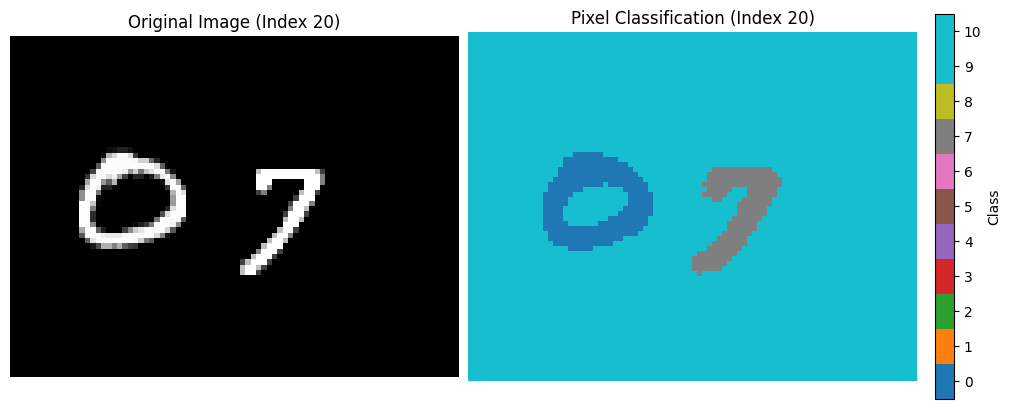

In [4]:
# Attack and example-image configuration. Change image_index to inspect a different test image.
num_max_pixels_attack = 25
image_index = 20
attack_type = "ubaa_darkening"
de = 1e-5   # small numerical slack for ImageStar predicate bounds
d = 150     # only pixels brighter than this threshold are attack candidates
delta = 0.0 # selected pixels can be fully darkened


in_data = image_data[:, :, :, image_index]
num_classes = net.layers[-1].classes

out_data = net.evaluate(in_data)
pix_class_labels = np.asarray(out_data).squeeze().astype(int)
class_cmap = plt.get_cmap("tab10", num_classes)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

axes[0].imshow(in_data.squeeze(), cmap="gray")
axes[0].set_title(f"Original Image (Index {image_index})")
axes[0].axis("off")

class_img = axes[1].imshow(
    pix_class_labels,
    cmap=class_cmap,
    vmin=-0.5,
    vmax=num_classes - 0.5,
    interpolation="nearest",
)
axes[1].set_title(f"Pixel Classification (Index {image_index})")
axes[1].axis("off")

cbar = fig.colorbar(class_img, ax=axes[1], ticks=np.arange(num_classes), fraction=0.046, pad=0.04)
cbar.set_label("Class")
plt.show()


## 3. UBAA Darkening Attack Visualization

The UBAA darkening attack is a bounded pixel attack. It does not choose one fixed corrupted image; it describes a family of possible corrupted images. In plain language, we let the attacker choose a small set of bright pixels and make those pixels darker. The verifier then asks: for every image the attacker is allowed to create, can the network still be proven to give the same pixel classification?

A pixel is eligible for attack when its intensity is greater than the threshold `d`. The attack can darken at most `num_max` eligible pixels. The parameter `delta` controls how much intensity remains after darkening: `delta = 0.0` makes selected pixels fully dark, while larger values preserve more brightness. In this tutorial, increasing `num_max` makes the attack set larger because more pixels may be changed.

Mathematically, let the nominal image be $x \in \mathbb{R}^{h \times w \times ch}$. For this grayscale M2NIST example, $ch=1$, so $x_{ij}$ denotes the intensity at pixel $(i,j)$. Let $S$ be the set of attacked pixels:

$$
S \subseteq \{(i,j) : x_{ij} > d\}, \qquad |S| \leq n_{\max}.
$$

A darkened image $x'$ is then defined pixel-wise as

$$
x'_{ij} =
\begin{cases}
\delta x_{ij}, & \text{if } (i,j) \in S, \\
x_{ij}, & \text{if } (i,j) \notin S.
\end{cases}
$$

The single-predicate StarV encoding used here represents this attack family with one attack direction $v$ and one bounded predicate variable $\alpha$:

$$
\mathcal{X}
= \left\{x + \alpha v \;:\; \alpha \in [1-\varepsilon, 1],\; C\alpha \leq b \right\}.
$$

Here, $v$ contains the darkening direction for the selected attackable pixels, and $\varepsilon$ corresponds to `de` in the code. This compact representation is useful because the verifier propagates the whole set $\mathcal{X}$, rather than testing one attacked image at a time.

As the number of attacked pixels increases, the attack set usually becomes harder to verify. We therefore expect the average robustness value `RV` to decrease because fewer pixels can be proven robust, while robustness sensitivity `RS` tends to increase because more pixels become unknown or non-robust relative to the attack budget. Runtime and memory depend on the reachable-set representation: dense `ImageStar` can be fast for this small single-predicate disturbance, while sparse COO/CSR representations can save memory when most generator entries are zero, but may introduce extra sparse-operation overhead.

This M2NIST segmentation network has 11 pixel classes. Classes `0` through `9` are digit classes. Class `10` is the background or non-digit class, so a pixel classified as class `10` is predicted to be background rather than part of a digit.

Before running formal verification, the next cell shows three concrete attacked images. These are examples from the attack idea, not the full verification set. The overlap column compares each attacked prediction with the original prediction: green means the class stayed the same, and red means the class changed.


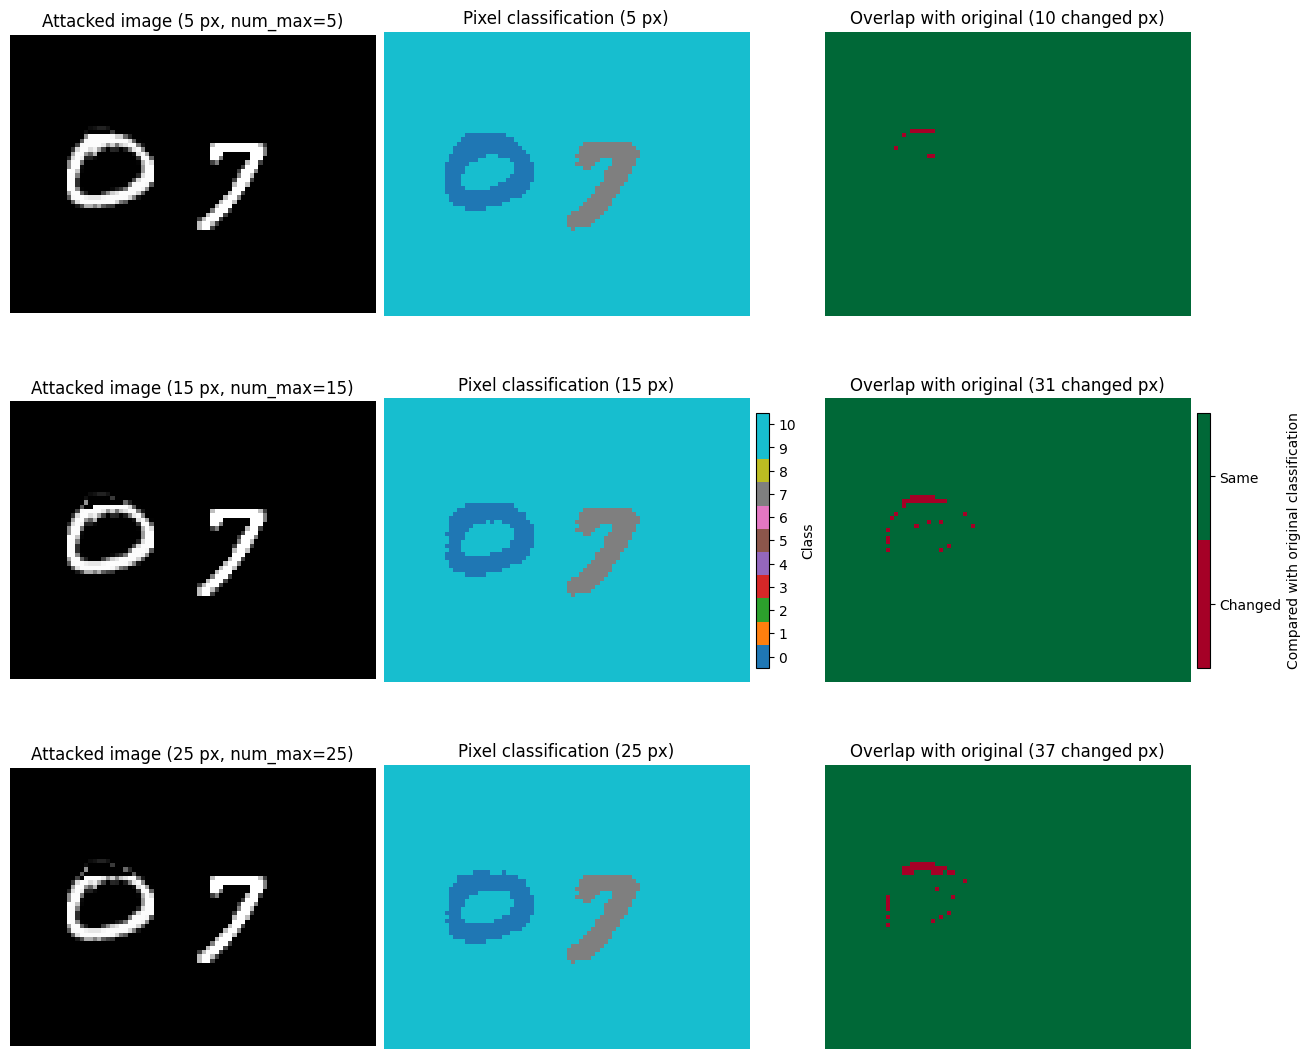

In [5]:
# Three attack budgets make the visual effect easier to see.
ubaa_demo_configs = [
    {"num_max": 5, "delta": delta, "d": d},
    {"num_max": 15, "delta": delta, "d": d},
    {"num_max": num_max_pixels_attack, "delta": delta, "d": d},
]

overlap_cmap = plt.get_cmap("RdYlGn", 2)
fig, axes = plt.subplots(len(ubaa_demo_configs), 3, figsize=(13, 11), constrained_layout=True)
class_cmap = plt.get_cmap("tab10", num_classes)
class_img = None
overlap_img = None

for row, cfg in enumerate(ubaa_demo_configs):
    attack_budget = cfg["num_max"]
    attack_noise = UBAA_darkening_attack(
        in_data,
        num_max=attack_budget,
        delta=cfg["delta"],
        d=cfg["d"],
        dtype=dtype,
    )
    attacked_image = np.clip(in_data.astype(dtype) + attack_noise, 0, 255)
    attacked_labels = np.asarray(net.evaluate(attacked_image)).squeeze().astype(int)
    attacked_pixels = np.count_nonzero(np.asarray(attack_noise).squeeze())
    same_as_original = attacked_labels == pix_class_labels
    changed_pixels = same_as_original.size - np.count_nonzero(same_as_original)

    axes[row, 0].imshow(attacked_image.squeeze(), cmap="gray")
    axes[row, 0].set_title(f"Attacked image ({attacked_pixels} px, num_max={attack_budget})")
    axes[row, 0].axis("off")

    class_img = axes[row, 1].imshow(
        attacked_labels,
        cmap=class_cmap,
        vmin=-0.5,
        vmax=num_classes - 0.5,
        interpolation="nearest",
    )
    axes[row, 1].set_title(f"Pixel classification ({attacked_pixels} px)")
    axes[row, 1].axis("off")

    overlap_img = axes[row, 2].imshow(
        same_as_original.astype(int),
        cmap=overlap_cmap,
        vmin=-0.5,
        vmax=1.5,
        interpolation="nearest",
    )
    axes[row, 2].set_title(f"Overlap with original ({changed_pixels} changed px)")
    axes[row, 2].axis("off")

class_cbar = fig.colorbar(class_img, ax=axes[:, 1], ticks=np.arange(num_classes), fraction=0.035, pad=0.02)
class_cbar.set_label("Class")

overlap_cbar = fig.colorbar(overlap_img, ax=axes[:, 2], ticks=[0, 1], fraction=0.035, pad=0.02)
overlap_cbar.ax.set_yticklabels(["Changed", "Same"])
overlap_cbar.set_label("Compared with original classification")
plt.show()


## 4. Build Reachable Input Sets

The attack examples above were concrete images. Formal verification needs a symbolic set that contains all images allowed by the attack parameters. StarV represents that set as an `ImageStar` or a sparse `SparseImageStar2DCSR`/`SparseImageStar2DCOO` object. These set objects are propagated through the network layer by layer.

The lower/upper-bound plots summarize the input set. If the lower and upper images are identical at a pixel, that pixel is fixed. If they differ, the attack can change that pixel within the shown range.


In [6]:
# Build the same attack set using three StarV representations.
# Dense ImageStar is easiest to inspect; sparse variants often reduce memory.
IM = create_reachable_set(in_data, 'ImageStar', attack_type, num_max=num_max_pixels_attack, de=de, d=d, delta=delta, dtype=dtype)
CSR = create_reachable_set(in_data, 'SparseImageStar2DCSR', attack_type, num_max=num_max_pixels_attack, de=de, d=d, delta=delta, dtype=dtype)
COO = create_reachable_set(in_data, 'SparseImageStar2DCOO', attack_type, num_max=num_max_pixels_attack, de=de, d=d, delta=delta, dtype=dtype)

input_sets = {
    'ImageStar': as_list(IM),
    'SparseImageStar2DCSR': as_list(CSR),
    'SparseImageStar2DCOO': as_list(COO),
}


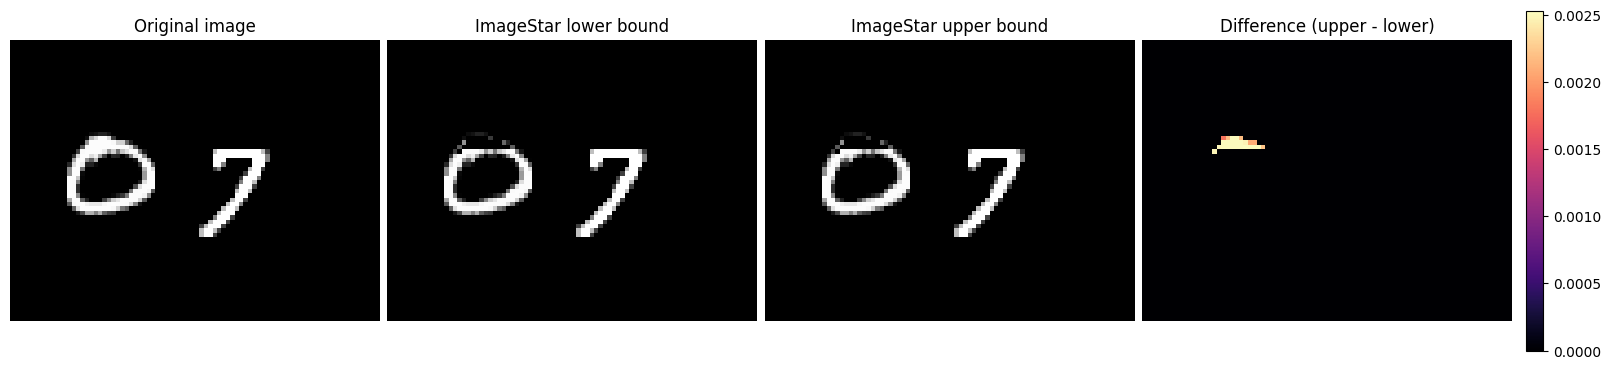

In [7]:
# Lower and upper bounds summarize what each pixel can become under the attack.
# Bright pixels in the difference image mark attack-controlled uncertainty.
imagestar_lb, imagestar_ub = IM.estimateRanges()
imagestar_lb = imagestar_lb.reshape(in_data.shape)
imagestar_ub = imagestar_ub.reshape(in_data.shape)
imagestar_bound_width = imagestar_ub - imagestar_lb

fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)

axes[0].imshow(in_data.squeeze(), cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(imagestar_lb.squeeze(), cmap="gray", vmin=0, vmax=255)
axes[1].set_title("ImageStar lower bound")
axes[1].axis("off")

axes[2].imshow(imagestar_ub.squeeze(), cmap="gray", vmin=0, vmax=255)
axes[2].set_title("ImageStar upper bound")
axes[2].axis("off")

bound_width_img = axes[3].imshow(imagestar_bound_width.squeeze(), cmap="magma", interpolation="nearest")
axes[3].set_title("Difference (upper - lower)")
axes[3].axis("off")
fig.colorbar(bound_width_img, ax=axes[3], fraction=0.046, pad=0.04)

plt.show()


## 5. Run Pixel-wise Robustness Verification

`certifyRobustness_pixel` propagates each input set through the segmentation network and classifies every output pixel. The output is not just one robust or unrobust answer for the whole image; it is a per-pixel verification result. This is important for semantic segmentation because different regions of the image can have different robustness behavior.

The solver setting `lp_solver = "gurobi"` is used for optimization subproblems inside reachability. If Gurobi is not available in your environment, this cell may need a different supported solver.


In [8]:
veriMethod = "BFS"
reachMethod = "approx"
lp_solver = "gurobi"

in_datas = as_list(in_data)

# certifyRobustness_pixel verifies a batch, so wrap our single image in a list.
verification_results = {}
verification_config = {
    "veriMethod": veriMethod,
    "reachMethod": reachMethod,
    "lp_solver": lp_solver,
}

for set_name, input_set in input_sets.items():
    print(f"Verifying {set_name}...")
    results = certifyRobustness_pixel(
        net,
        input_set,
        in_datas,
        num_classes,
        veriMethod,
        reachMethod,
        lp_solver,
        return_max_memory_usage=True,
    )
    verification_results[set_name] = results


Verifying ImageStar...
Verifying SparseImageStar2DCSR...
Verifying SparseImageStar2DCOO...


## 6. Verification and Memory Comparison

The verifier returns counts for robust, unknown, and unrobust or misclassified pixels. For tutorial purposes, read the plot as follows:

| Quantity | Meaning |
|---|---|
| Robust pixels | Pixels proven to keep the same class as the original image for every allowed attack. |
| Unknown pixels | Pixels where the verifier could not prove a unique unchanged class. |
| Unrobust/misclassified pixels | Pixels whose verified result does not match the original pixel class. |
| Verification time | Total time for the selected set representation. |
| Max memory | Peak reachable-set memory reported by the verifier. |

`ImageStar` is the dense representation. `SparseImageStar2DCOO` and `SparseImageStar2DCSR` store sparse generators and constraints, which can reduce memory when most pixels are unaffected by the attack.


,Set,Robust pixels,Unknown pixels,Misclassified pixels,Attacked pixels,Robust IoU,Robust rate,Verification time (s),Max memory (GB)
0,ImageStar,5339.0,0.0,37.0,25.0,0.7171,0.9931,2.1317,0.0961
1,SparseImageStar2DCSR,5339.0,0.0,37.0,25.0,0.7171,0.9931,115.4390,0.0909
2,SparseImageStar2DCOO,5339.0,0.0,37.0,25.0,0.7171,0.9931,114.3050,0.0732


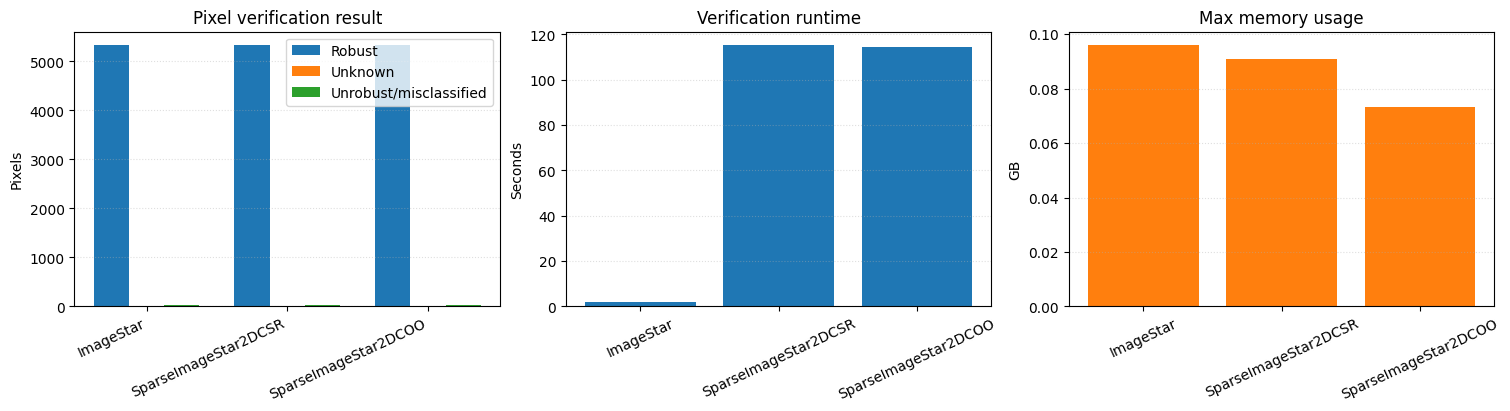

In [9]:
summary_rows = []
for set_name, result in verification_results.items():
    avg_num_rb, avg_num_unk, avg_num_mis, avg_num_att, avg_riou, avg_rv, avg_rs, avg_vt, max_memory_used = result["average_data"]
    summary_rows.append({
        "Set": set_name,
        "Robust pixels": avg_num_rb,
        "Unknown pixels": avg_num_unk,
        "Misclassified pixels": avg_num_mis,
        "Attacked pixels": avg_num_att,
        "Robust IoU": avg_riou,
        "Robust rate": avg_rv,
        "Verification time (s)": avg_vt,
        "Max memory (GB)": max_memory_used / (1024**3),
    })

try:
    import pandas as pd
    verification_summary_table = pd.DataFrame(summary_rows)
    display(verification_summary_table.round(4))
except ImportError:
    verification_summary_table = summary_rows
    for row in verification_summary_table:
        print(row)

set_names = [row["Set"] for row in summary_rows]
robust_pixels = [row["Robust pixels"] for row in summary_rows]
unknown_pixels = [row["Unknown pixels"] for row in summary_rows]
misclassified_pixels = [row["Misclassified pixels"] for row in summary_rows]
verification_times = [row["Verification time (s)"] for row in summary_rows]
max_memory_gb = [row["Max memory (GB)"] for row in summary_rows]

x = np.arange(len(set_names))
width = 0.25
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].bar(x - width, robust_pixels, width, label="Robust")
axes[0].bar(x, unknown_pixels, width, label="Unknown")
axes[0].bar(x + width, misclassified_pixels, width, label="Unrobust/misclassified")
axes[0].set_title("Pixel verification result")
axes[0].set_ylabel("Pixels")
axes[0].set_xticks(x)
axes[0].set_xticklabels(set_names, rotation=25, ha="right")
axes[0].grid(axis="y", linestyle=":", alpha=0.4)
axes[0].legend()

axes[1].bar(set_names, verification_times, color="tab:blue")
axes[1].set_title("Verification runtime")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", linestyle=":", alpha=0.4)

axes[2].bar(set_names, max_memory_gb, color="tab:orange")
axes[2].set_title("Max memory usage")
axes[2].set_ylabel("GB")
axes[2].tick_params(axis="x", rotation=25)
axes[2].grid(axis="y", linestyle=":", alpha=0.4)

plt.show()


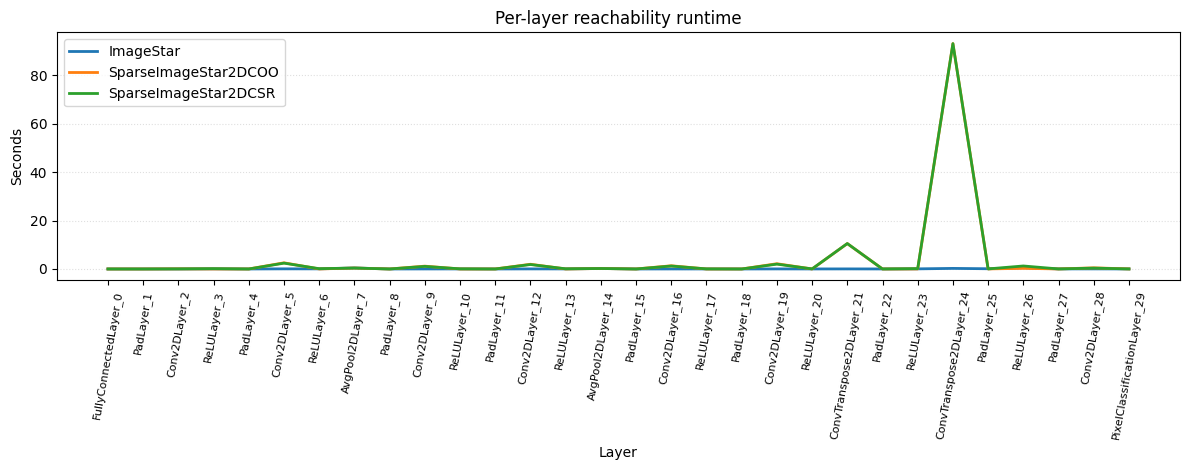

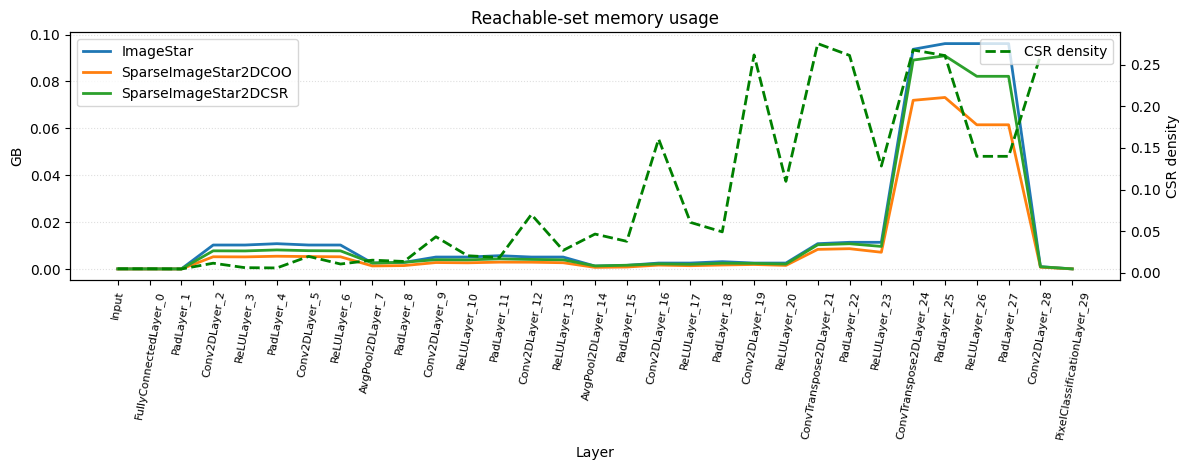

In [10]:
# Optional deeper diagnostic: profile each network layer. This can be slow, so
# it is disabled by default. Set RUN_LAYER_PROFILE = True to use it.
RUN_LAYER_PROFILE = False

if RUN_LAYER_PROFILE:
    import copy

    def _single_reach_set(value):
        if isinstance(value, list):
            return value[0] if len(value) == 1 else value
        return value

    def _object_nbytes(value):
        if isinstance(value, list):
            return sum(_object_nbytes(v) for v in value)
        if isinstance(value, dict):
            return sum(np.asarray(v).nbytes for v in value.values() if isinstance(v, np.ndarray))
        if hasattr(value, "nbytes") and callable(value.nbytes):
            return value.nbytes()
        if hasattr(value, "nbytes"):
            return value.nbytes
        return 0

    def _object_density(value):
        value = _single_reach_set(value)
        return value.density() if hasattr(value, "density") else np.nan

    profile_sets = {
        "ImageStar": copy.deepcopy(IM),
        "SparseImageStar2DCOO": copy.deepcopy(COO),
        "SparseImageStar2DCSR": copy.deepcopy(CSR),
    }
    profile_time = {name: [] for name in profile_sets}
    profile_memory = {name: [_object_nbytes(set_obj) / (1024**3)] for name, set_obj in profile_sets.items()}
    csr_density = [_object_density(profile_sets["SparseImageStar2DCSR"])]

    for layer_index, layer in enumerate(net.layers):
        for set_name, set_obj in list(profile_sets.items()):
            start = time.perf_counter()
            profile_sets[set_name] = layer.reach(
                set_obj,
                method=reachMethod,
                lp_solver=lp_solver,
                show=False,
            )
            profile_sets[set_name] = _single_reach_set(profile_sets[set_name])
            profile_time[set_name].append(time.perf_counter() - start)
            profile_memory[set_name].append(_object_nbytes(profile_sets[set_name]) / (1024**3))
        csr_density.append(_object_density(profile_sets["SparseImageStar2DCSR"]))

    layer_ids = np.arange(net.n_layers)
    layer_labels = [f"{layer.__class__.__name__}_{i}" for i, layer in enumerate(net.layers)]

    fig, ax = plt.subplots(figsize=(12, 4.8))
    for set_name, times in profile_time.items():
        ax.plot(layer_ids, times, linewidth=2, label=set_name)
    ax.set_title("Per-layer reachability runtime")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Seconds")
    ax.set_xticks(layer_ids)
    ax.set_xticklabels(layer_labels, rotation=80, fontsize=8)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.show()

    memory_ids = np.arange(net.n_layers + 1)
    memory_labels = ["Input", *layer_labels]
    fig, ax = plt.subplots(figsize=(12, 4.8))
    for set_name, memory in profile_memory.items():
        ax.plot(memory_ids, memory, linewidth=2, label=set_name)
    ax.set_title("Reachable-set memory usage")
    ax.set_xlabel("Layer")
    ax.set_ylabel("GB")
    ax.set_xticks(memory_ids)
    ax.set_xticklabels(memory_labels, rotation=80, fontsize=8)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.legend(loc="upper left")

    ax_density = ax.twinx()
    ax_density.plot(memory_ids, csr_density, color="green", linewidth=2, linestyle="--", label="CSR density")
    ax_density.set_ylabel("CSR density")
    ax_density.legend(loc="upper right")
    plt.tight_layout()
    plt.show()
else:
    print("Set RUN_LAYER_PROFILE = True to run the optional layer profiling cell.")


## 7. Inspect ImageStar Pixel Classification Results

The next figures focus on the dense `ImageStar` result because it is the easiest representation to explain visually. `pixel_labels` gives the verifier's single-label output. `pixel_multiclass_labels` is richer: for each pixel and class, it records whether that class is reachable under some allowed attack.

A pixel with exactly one reachable class is easier to certify. A pixel with multiple reachable classes is an uncertainty region: different allowed attacks may lead to different pixel classifications, or the over-approximation may be too loose to prove one class.


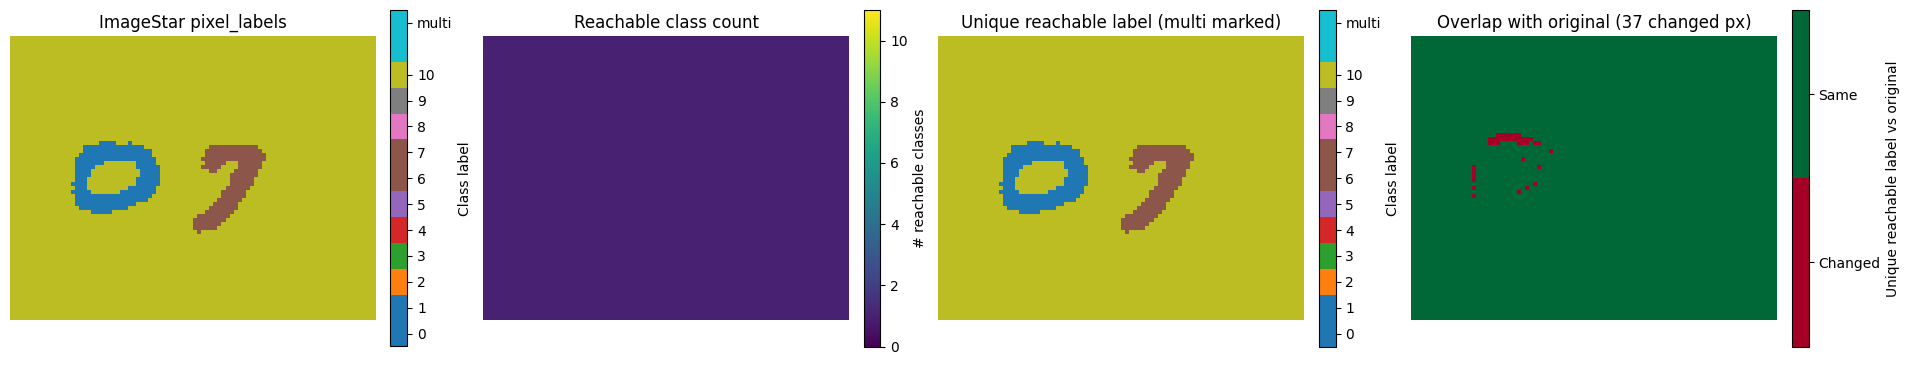

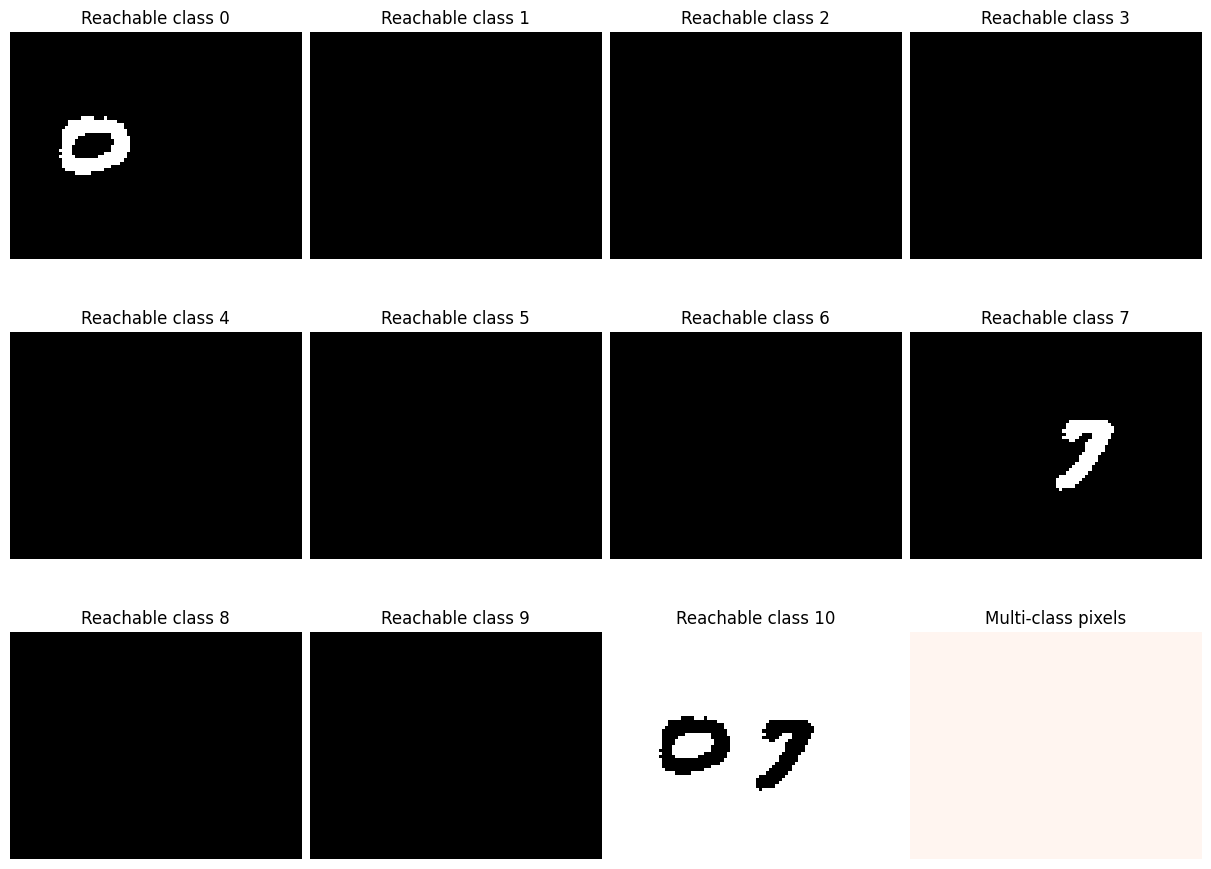

In [11]:
# Inspect the dense ImageStar result because it is easiest to explain visually.
imagestar_results = verification_results["ImageStar"]
imagestar_pixel_labels = np.asarray(imagestar_results["pixel_labels"][0]).squeeze().astype(int)
imagestar_multiclass_labels = np.asarray(imagestar_results["pixel_multiclass_labels"][0]).astype(bool)
imagestar_ground_truth_labels = np.asarray(imagestar_results["ground_truth_pixel_labels"][0]).squeeze().astype(int)

reachable_class_count = imagestar_multiclass_labels.sum(axis=2)
unique_reachable_labels = np.argmax(imagestar_multiclass_labels, axis=2)
unique_reachable_labels[reachable_class_count != 1] = num_classes + 1
reachable_same_as_original = unique_reachable_labels == imagestar_ground_truth_labels
reachable_changed_pixels = reachable_same_as_original.size - np.count_nonzero(reachable_same_as_original)

fig, axes = plt.subplots(1, 4, figsize=(19, 4), constrained_layout=True)
class_cmap = plt.get_cmap("tab10", num_classes + 2)
overlap_cmap = plt.get_cmap("RdYlGn", 2)

label_img = axes[0].imshow(
    imagestar_pixel_labels,
    cmap=class_cmap,
    vmin=-0.5,
    vmax=num_classes + 1.5,
    interpolation="nearest",
)
axes[0].set_title("ImageStar pixel_labels")
axes[0].axis("off")
label_ticks = list(range(num_classes)) + [num_classes + 1]
label_tick_names = [str(i) for i in range(num_classes)] + ["multi"]
label_cbar = fig.colorbar(label_img, ax=axes[0], ticks=label_ticks, fraction=0.046, pad=0.04)
label_cbar.ax.set_yticklabels(label_tick_names)
label_cbar.set_label("Class label")

count_img = axes[1].imshow(
    reachable_class_count,
    cmap="viridis",
    vmin=0,
    vmax=num_classes,
    interpolation="nearest",
)
axes[1].set_title("Reachable class count")
axes[1].axis("off")
count_cbar = fig.colorbar(count_img, ax=axes[1], fraction=0.046, pad=0.04)
count_cbar.set_label("# reachable classes")

unique_img = axes[2].imshow(
    unique_reachable_labels,
    cmap=class_cmap,
    vmin=-0.5,
    vmax=num_classes + 1.5,
    interpolation="nearest",
)
axes[2].set_title("Unique reachable label (multi marked)")
axes[2].axis("off")
unique_cbar = fig.colorbar(unique_img, ax=axes[2], ticks=label_ticks, fraction=0.046, pad=0.04)
unique_cbar.ax.set_yticklabels(label_tick_names)
unique_cbar.set_label("Class label")

overlap_img = axes[3].imshow(
    reachable_same_as_original.astype(int),
    cmap=overlap_cmap,
    vmin=-0.5,
    vmax=1.5,
    interpolation="nearest",
)
axes[3].set_title(f"Overlap with original ({reachable_changed_pixels} changed px)")
axes[3].axis("off")
overlap_cbar = fig.colorbar(overlap_img, ax=axes[3], ticks=[0, 1], fraction=0.046, pad=0.04)
overlap_cbar.ax.set_yticklabels(["Changed", "Same"])
overlap_cbar.set_label("Unique reachable label vs original")
plt.show()

fig, axes = plt.subplots(3, 4, figsize=(12, 9), constrained_layout=True)
axes = axes.ravel()
for class_id in range(num_classes):
    axes[class_id].imshow(imagestar_multiclass_labels[:, :, class_id], cmap="gray", interpolation="nearest")
    axes[class_id].set_title(f"Reachable class {class_id}")
    axes[class_id].axis("off")

axes[num_classes].imshow(reachable_class_count > 1, cmap="Reds", interpolation="nearest")
axes[num_classes].set_title("Multi-class pixels")
axes[num_classes].axis("off")
plt.show()


## 8. ImageStar Semantic Metric Summary

The ImageStar verification result gives two complementary pixel-classification outputs. `pixel_labels` records the single verified label when the verifier can assign one. `pixel_multiclass_labels` records every class that is reachable for each pixel, so it can represent uncertainty directly.

The first rows in the table follow the pixel-wise verification algorithm notation. `n_rb` counts pixels proven robust, `n_unk` counts pixels whose original class is still reachable but not unique, and `n_not-rb` counts pixels where the original class is not reachable. `RV` is the robust value, the fraction of all image pixels that are robust. `RS` is robust sensitivity, the number of unknown plus non-robust pixels normalized by the attack budget. `RIoU` is the robust Intersection-over-Union between the nominal mask and the verified mask.

The metric names refer to three related but different views of the verification result:

| Metric family | Uses | Meaning |
|---|---|---|
| Worst-case robust (`WCR...`) | The reachable multiclass labels `pixel_multiclass_labels`. | Measures the score under the least favorable semantic class assignment allowed by the reachable set. It asks: if the attack pushes every uncertain pixel in the worst allowed direction, how much agreement with the nominal mask remains? |
| Verification-aware robust (`VR...`) | The hard verification image `verified_image`. | Measures agreement after explicitly treating verification outcomes such as unknown or unrobust/misclassified pixels as failure states. It asks: how good is the mask when we only trust pixels that the verifier could certify? |
| Verification-aware worst-case robust (`VB...`) | The reachable multiclass labels plus an explicit verification-failure state. | Combines both ideas: uncertain reachable classes are evaluated pessimistically, and verification failures are included as labels that penalize the score. It asks: what is the conservative worst-case score when verification uncertainty is also counted? |

These families are not guaranteed to be numerically ordered in every case because they are computed from different representations. For example, a verification-aware robust score can be lower than a verification-aware worst-case score when the hard failure-state image disrupts region or skeleton structure more than the reachable-set worst-case proxy.

Except for the pixel-count rows, values are in `[0, 1]`; higher is better. A value of `1.0` means perfect agreement under that metric.

| Value | Measures | Interpretation |
|---|---|---|
| `n_rb` | Number of robust pixels | Pixels where the nominal class is reachable and is the only reachable class. |
| `n_unk` | Number of unknown pixels | Pixels where the nominal class is reachable, but multiple classes are possible. |
| `n_not-rb` | Number of non-robust pixels | Pixels where the nominal class is not reachable under the attack set. |
| `RV` | Robust value | Fraction of all image pixels that are verified robust: `n_rb / (h*w)`. |
| `RS` | Robust sensitivity | Attack-normalized uncertain or non-robust pixels: `(n_unk + n_not-rb) / n_atk`. |
| `RIoU` | Robust Intersection-over-Union | IoU between the nominal pixel mask and the verified pixel mask. |
| `WCRIoU` | Worst-case robust Intersection-over-Union | Region overlap between original pixel classes and the least favorable reachable class assignment. |
| `WCRDice` | Worst-case robust Dice score | Region similarity, with stronger emphasis on overlap balance than IoU. |
| `WCRBIoU` | Worst-case robust Boundary IoU | Agreement of object/class boundaries under the least favorable reachable classification. |
| `WCRclDice` | Worst-case robust centerline Dice | Topology/skeleton-style agreement, useful for thin or connected structures. |
| `VRIoU` | Verification-aware robust IoU | IoU after treating unknown and unrobust states as explicit failure labels. |
| `VBIoU` | Verification-aware worst-case robust IoU | Worst-case IoU computed from reachable labels with verification failure states included. |
| `VRDice` | Verification-aware robust Dice | Dice score with verification failure states included. |
| `VBDice` | Verification-aware worst-case robust Dice | Worst-case Dice score with verification failure states included. |
| `VRBIoU` | Verification-aware robust Boundary IoU | Boundary IoU with verification failure states included. |
| `VBBIoU` | Verification-aware worst-case robust Boundary IoU | Worst-case boundary agreement with verification failure states included. |
| `VRclDice` | Verification-aware robust centerline Dice | Centerline/topology agreement with verification failure states included. |
| `VBclDice` | Verification-aware worst-case centerline Dice | Worst-case centerline/topology agreement with verification failure states included. |


In [12]:
imagestar_results = verification_results["ImageStar"]
imagestar_pixel_labels = imagestar_results["pixel_labels"][0]
imagestar_multiclass_labels = imagestar_results["pixel_multiclass_labels"][0]
imagestar_ground_truth_labels = imagestar_results["ground_truth_pixel_labels"][0]
imagestar_verified_image = imagestar_results["verified_images"]
(
    imagestar_n_rb,
    imagestar_n_unk,
    imagestar_n_not_rb,
    imagestar_n_atk,
    imagestar_riou,
    imagestar_rv,
    imagestar_rs,
    imagestar_verification_time,
    imagestar_max_memory_used,
) = imagestar_results["average_data"]

wcr_iou, wcr_dice, wcr_boundary_iou, wcr_cldice = compute_evaluation_results(
    imagestar_ground_truth_labels,
    imagestar_multiclass_labels,
    num_classes=num_classes,
    robust_mode="unique",
)
verification_aware_metrics = compute_verification_aware_evaluation_results(
    imagestar_ground_truth_labels,
    imagestar_verified_image,
    imagestar_multiclass_labels,
    num_classes=num_classes,
)

imagestar_metric_rows = [
    {"Value": "n_rb", "Score": imagestar_n_rb, "Measures": "Number of robust pixels"},
    {"Value": "n_unk", "Score": imagestar_n_unk, "Measures": "Number of unknown pixels"},
    {"Value": "n_not-rb", "Score": imagestar_n_not_rb, "Measures": "Number of non-robust pixels"},
    {"Value": "RV", "Score": imagestar_rv, "Measures": "Robust value"},
    {"Value": "RS", "Score": imagestar_rs, "Measures": "Robust sensitivity"},
    {"Value": "RIoU", "Score": imagestar_riou, "Measures": "Robust IoU"},
    {"Value": "WCRIoU", "Score": wcr_iou, "Measures": "Worst-case robust region overlap"},
    {"Value": "WCRDice", "Score": wcr_dice, "Measures": "Worst-case robust region similarity"},
    {"Value": "WCRBIoU", "Score": wcr_boundary_iou, "Measures": "Worst-case robust boundary agreement"},
    {"Value": "WCRclDice", "Score": wcr_cldice, "Measures": "Worst-case robust centerline/topology agreement"},
    {"Value": "VRIoU", "Score": verification_aware_metrics["verification_aware_average_r_iou"], "Measures": "Verification-aware robust region overlap"},
    {"Value": "VBIoU", "Score": verification_aware_metrics["verification_aware_average_wc_r_iou"], "Measures": "Verification-aware worst-case region overlap"},
    {"Value": "VRDice", "Score": verification_aware_metrics["verification_aware_average_r_dice"], "Measures": "Verification-aware robust Dice similarity"},
    {"Value": "VBDice", "Score": verification_aware_metrics["verification_aware_average_wc_r_dice"], "Measures": "Verification-aware worst-case Dice similarity"},
    {"Value": "VRBIoU", "Score": verification_aware_metrics["verification_aware_average_r_boundary_iou"], "Measures": "Verification-aware robust boundary agreement"},
    {"Value": "VBBIoU", "Score": verification_aware_metrics["verification_aware_average_wc_r_boundary_iou"], "Measures": "Verification-aware worst-case boundary agreement"},
    {"Value": "VRclDice", "Score": verification_aware_metrics["verification_aware_average_r_cldice"], "Measures": "Verification-aware robust centerline/topology agreement"},
    {"Value": "VBclDice", "Score": verification_aware_metrics["verification_aware_average_wc_r_cldice"], "Measures": "Verification-aware worst-case centerline/topology agreement"},
]

count_values = {"n_rb", "n_unk", "n_not-rb"}
imagestar_metric_table = pd.DataFrame(imagestar_metric_rows)
imagestar_metric_table["Score"] = [
    f"{float(score):.0f}" if value in count_values else f"{float(score):.4f}"
    for value, score in zip(imagestar_metric_table["Value"], imagestar_metric_table["Score"])
]
display(imagestar_metric_table)


,Value,Score,Measures
0,n_rb,5339,Number of robust pixels
1,n_unk,0,Number of unknown pixels
2,n_not-rb,37,Number of non-robust pixels
3,RV,0.9931,Robust value
4,RS,1.4800,Robust sensitivity
5,RIoU,0.7171,Robust IoU
6,WCRIoU,0.9508,Worst-case robust region overlap
7,WCRDice,0.9736,Worst-case robust region similarity
8,WCRBIoU,0.9300,Worst-case robust boundary agreement
9,WCRclDice,1.0000,Worst-case robust centerline/topology agreement
